In [1]:
import os
import sys

import cv2
import numpy as np
import torch

sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('__file__')), '..'))
from model_spillnet import SpillNet

In [2]:
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

BASE_DIR   = './dataset/test_xl'
INPUT_DIR  = os.path.join(BASE_DIR, 'image_xl')    # raw frames  
FG_DIR     = os.path.join(BASE_DIR, 'fg_xl')        # fg with alpha channel  
OUTPUT_DIR = os.path.join(BASE_DIR, 'output_xl')    # despilled rgba output 
IMAGE_A_DIR = os.path.join(BASE_DIR, 'image_a_xl')  # raw image + gt alpha  

MODEL_PATH = './checkpoints/stage1_spillnet/best.pth'

os.makedirs(OUTPUT_DIR,  exist_ok=True)
os.makedirs(IMAGE_A_DIR, exist_ok=True)

In [3]:
model = SpillNet(base=64).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()
print(f"model loaded, running on {DEVICE}")

model loaded, running on cuda


In [4]:
def predict_rgba(img_path, fg_path, infer_size=512):
    """
    run spillnet on a single frame, return rgba result at original resolution

    alpha is taken from the fg png's alpha channel, with slight edge blur

    """
    image    = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    h_orig, w_orig = image.shape[:2]
    image_np = image.astype(np.float32) / 255.0

    # read alpha from fg's A channel  
    fg       = cv2.imread(fg_path, cv2.IMREAD_UNCHANGED)   # bgra
    alpha_np = fg[:, :, 3].astype(np.float32) / 255.0

    # slight gaussian blur to soften hard edges  
    alpha_u8 = (alpha_np * 255).astype(np.uint8)
    alpha_u8 = cv2.GaussianBlur(alpha_u8, (7, 7), 0)
    alpha_np = alpha_u8.astype(np.float32) / 255.0

    # resize to inference size  
    image_s = cv2.resize(image_np, (infer_size, infer_size))
    alpha_s = cv2.resize(alpha_np, (infer_size, infer_size))

    image_t = torch.from_numpy(image_s).permute(2, 0, 1).unsqueeze(0).float().to(DEVICE)
    alpha_t = torch.from_numpy(alpha_s).unsqueeze(0).unsqueeze(0).float().to(DEVICE)

    with torch.no_grad():
        pred = model(image_t, alpha_t)

    # restore to original resolution  
    pred_np = pred.squeeze(0).permute(1, 2, 0).cpu().numpy()
    pred_np = np.clip(cv2.resize(pred_np, (w_orig, h_orig), interpolation=cv2.INTER_LINEAR), 0, 1)

    # pack rgb + alpha into rgba  
    rgba = np.concatenate([pred_np, alpha_np[:, :, np.newaxis]], axis=2)
    return rgba, h_orig, w_orig

In [5]:
exts   = ('.png', '.jpg', '.jpeg')
frames = sorted([f for f in os.listdir(INPUT_DIR) if f.lower().endswith(exts)])
print(f"found {len(frames)}")

for i, fname in enumerate(frames):
    img_path = os.path.join(INPUT_DIR, fname)
    fg_path  = os.path.join(FG_DIR,    fname)

    rgba, h, w = predict_rgba(img_path, fg_path)

    # convert rgba -> bgra for cv2  
    bgra = cv2.cvtColor((rgba * 255).clip(0, 255).astype(np.uint8), cv2.COLOR_RGBA2BGRA)
    out_path = os.path.join(OUTPUT_DIR, os.path.splitext(fname)[0] + '.png')
    cv2.imwrite(out_path, bgra)

    if (i + 1) % 50 == 0 or (i + 1) == len(frames):
        print(f"  [{i+1}/{len(frames)}] {fname} -> {out_path}")

    torch.cuda.empty_cache()

print("done.")

found 25
  [25/25] 2_12_25.png -> ./dataset/test_xl/output_xl/2_12_25.png
done.


In [6]:
frames = sorted([f for f in os.listdir(INPUT_DIR) if f.lower().endswith(exts)])
print(f"found {len(frames)}")

for i, fname in enumerate(frames):
    img_bgr = cv2.imread(os.path.join(INPUT_DIR, fname), cv2.IMREAD_COLOR)

    # pull alpha from fg png  
    fg    = cv2.imread(os.path.join(FG_DIR, fname), cv2.IMREAD_UNCHANGED)
    alpha = fg[:, :, 3]

    bgra = cv2.merge([img_bgr[:, :, 0], img_bgr[:, :, 1], img_bgr[:, :, 2], alpha])

    out_path = os.path.join(IMAGE_A_DIR, os.path.splitext(fname)[0] + '.png')
    cv2.imwrite(out_path, bgra)

    if (i + 1) % 50 == 0 or (i + 1) == len(frames):
        print(f"  [{i+1}/{len(frames)}] {fname} -> {out_path}")

print("done.")

found 25
  [25/25] 2_12_25.png -> ./dataset/test_xl/image_a_xl/2_12_25.png
done.


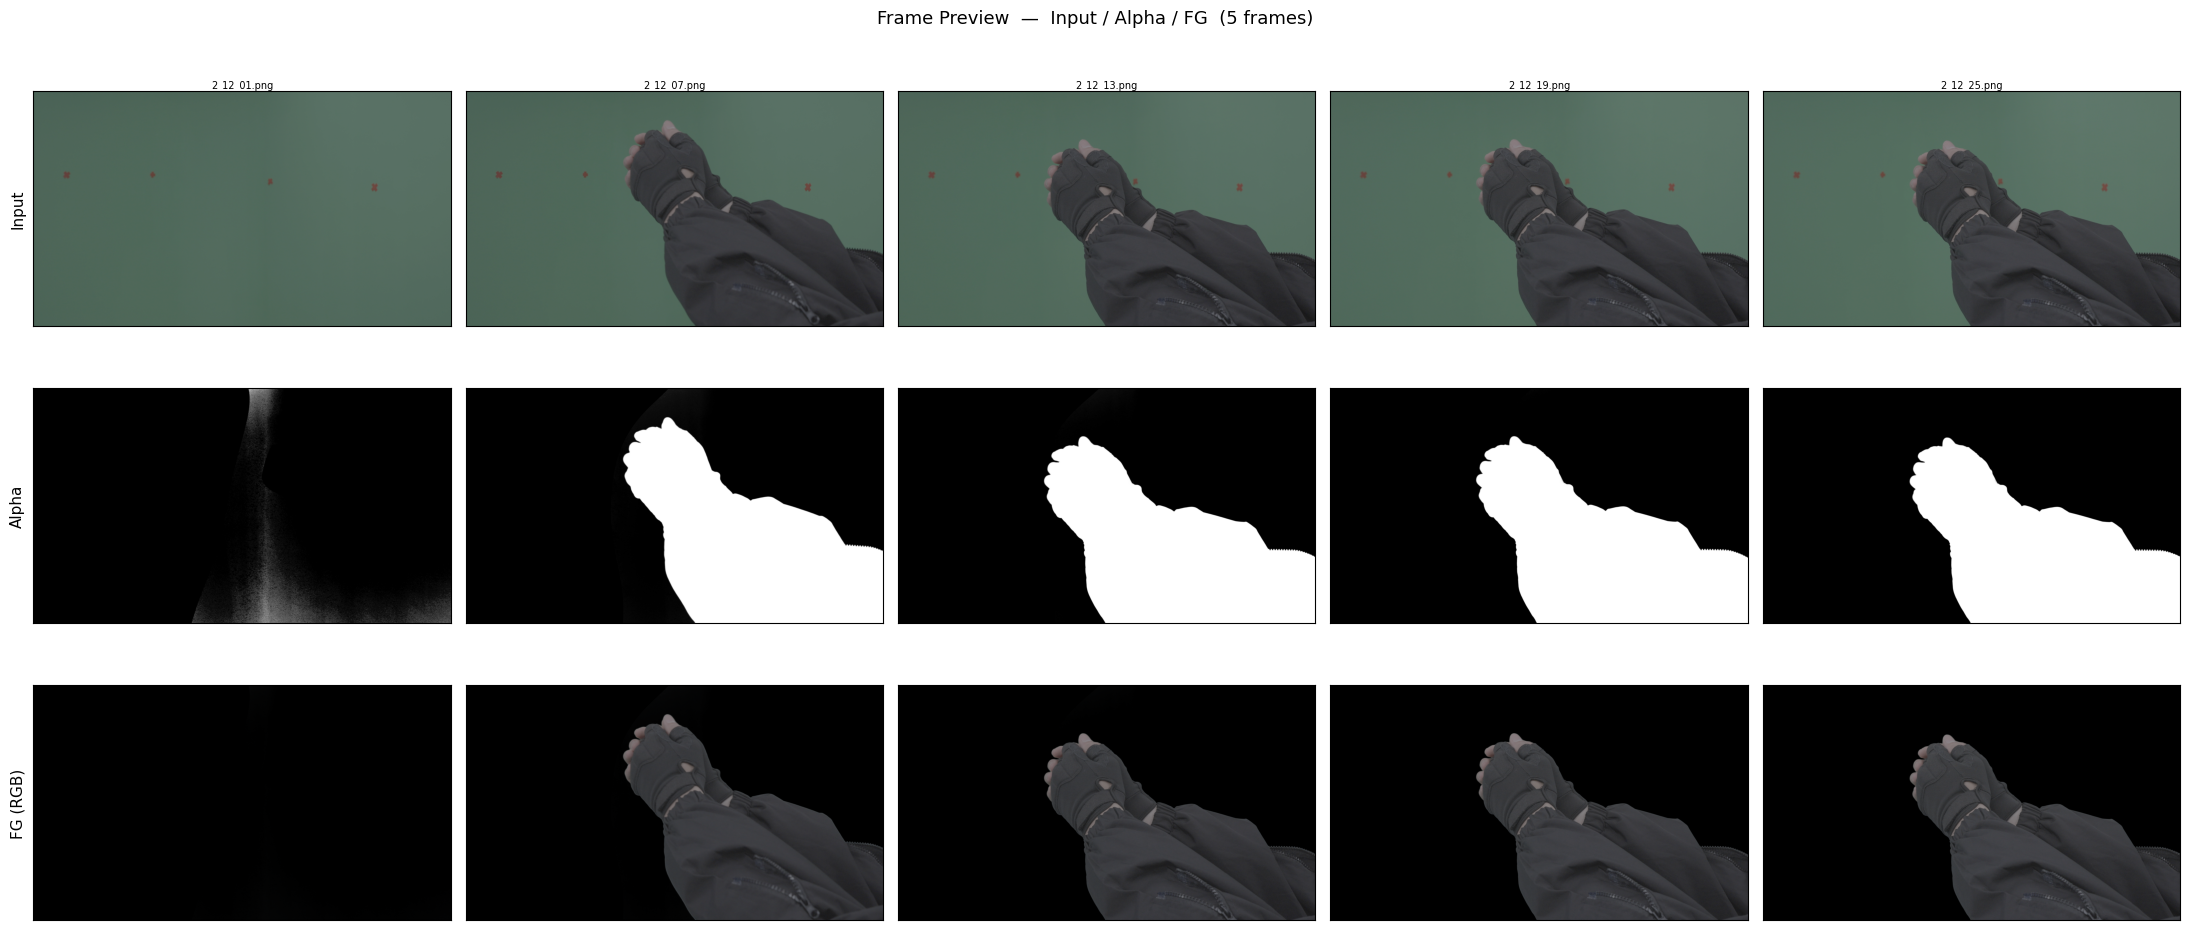

Total frames found — Input: 25  |  FG: 25


In [8]:
# Cell: Preview 5 frames — Input / Alpha / FG

import random
import matplotlib.pyplot as plt

img_files = sorted([f for f in os.listdir(INPUT_DIR) if f.lower().endswith(('.png', '.jpg'))])
fg_files  = sorted([f for f in os.listdir(FG_DIR)    if f.lower().endswith(('.png', '.jpg'))])

# pick 5 evenly spaced frames (or random — swap the line below)
indices   = np.linspace(0, len(img_files) - 1, 5, dtype=int)
# indices = sorted(random.sample(range(len(img_files)), 5))  # ← random alternative

fig, axes = plt.subplots(3, 5, figsize=(22, 10))
fig.suptitle('Frame Preview  —  Input / Alpha / FG  (5 frames)', fontsize=13)
row_labels = ['Input', 'Alpha', 'FG (RGB)']

for col, idx in enumerate(indices):
    img_path = os.path.join(INPUT_DIR, img_files[idx])
    fg_path  = os.path.join(FG_DIR,    fg_files[idx])

    image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    fg    = cv2.imread(fg_path, cv2.IMREAD_UNCHANGED)   # bgra

    image_np = image.astype(np.float32) / 255.0
    alpha_np = fg[:, :, 3].astype(np.float32) / 255.0
    fg_rgb   = cv2.cvtColor(fg[:, :, :3], cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

    axes[0, col].imshow(np.clip(image_np, 0, 1))
    axes[1, col].imshow(np.clip(alpha_np, 0, 1), cmap='gray')
    axes[2, col].imshow(np.clip(fg_rgb,   0, 1))

    axes[0, col].set_title(img_files[idx], fontsize=7, pad=3)

for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=11, labelpad=6)

for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

print(f"Total frames found — Input: {len(img_files)}  |  FG: {len(fg_files)}")
